
 <font size="6">
 <div class="alert alert-block alert-info"> <b>Redes neuronais convolucionais - Fashion Net<b>
     </div>
</font>

## Classificação de imagens de flores

Este notebook encontra-se segundo seis partes:
1. Importação das bibliotecas necessárias
2. Carregamento dos datasets
3. Definição de callbacks
4. Definição e compilação do modelo
5. Treino do modelo
6. Resultados

In [5]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

## Carregamento dos datasets

In [6]:
##############################################################################
# Preparação dos dados

# utilizar o dataset FASHION_MNIST builtin do tensorflow/keras
fashion_mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# normalização dos valores de pixel para o intervalo [0 ... 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# preparar os "targets" da ground truth para o formato adequado, usando 10 classes
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# como não estava definido um conjunto de validação, usaram-se algumas amostras de treino
TRAIN_VAL_SPLIT = 10000
x_val = x_train[:TRAIN_VAL_SPLIT,:]
y_val = y_train[:TRAIN_VAL_SPLIT,:]
x_train = x_train[TRAIN_VAL_SPLIT:,:]
y_train = y_train[TRAIN_VAL_SPLIT:,:]


# constantes - labels, classes e dimensões das imagens
LABELS = ["T-Shirt/Top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Boot"]
N_CLASSES = 10
IMG_HEIGHT = 28
IMG_WIDTH = 28

# mostrar as dimensões das matrizes para treino e teste
print("Training samples shape:   ", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Val samples shape:        ", x_val.shape)
print("Val labels shape:     ", y_val.shape)
print("Test samples shape:       ", x_test.shape)
print("Test labels shape:    ", y_test.shape)

Training samples shape:    (50000, 28, 28)
Training labels shape: (50000, 10)
Val samples shape:         (10000, 28, 28)
Val labels shape:      (10000, 10)
Test samples shape:        (10000, 28, 28)
Test labels shape:     (10000, 10)


## Definição dos callbacks
Foram definidos dois <i>callbacks</i>:

- `BEST_MODEL_CHECKPOINT` - para ir guardando o melhor modelo (por "melhor" entenda-se o que tem menor <i>loss</i>)
- `EARLY_STOPPING`- para terminar o treino quando não há melhorias na loss da validação durante <i>n</i> épocas consecutivas (<i>n</i> é definido pelo parâmetro `patience`, neste caso definiu-se 5)

In [7]:
# ficheiro onde serão guardados os pesos do "melhor modelo" - ajustar a gosto
BEST_MODEL_PATH = "tmp/best_model.weights.h5"

BEST_MODEL_CHECKPOINT = keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True)

EARLY_STOPPING = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5)

## Definição e compilação do modelo
O modelo definido é uma rede neuronal convolucional (CNN), muito simples, com camadas convolucionais intercaladas com camadas de pooling. Note-se que o modelo não está otimizado e pretende ser apenas um exemplo.

In [8]:
# definição do modelo
model = keras.models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])


# compilação do modelo - escolha do algoritmo de otimização e função de perda
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=['accuracy'])
# sumário
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Treino do modelo
Treinar com a função `fit(...)`. Em relação ao que já foi visto anteriormente, destaca-se o facto de agora não se especificar o batch_size, pois o `train_ds` já se encontra dividido em batches (a função `keras.utils.image_dataset_from_directory(...)` tratou disso).

In [9]:
# treino
nEpochs = 20
history = model.fit(x_train, y_train,
                    batch_size=64,
                    epochs=nEpochs,
                    validation_data=(x_val, y_val),
                    callbacks=[BEST_MODEL_CHECKPOINT, EARLY_STOPPING])

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8165 - loss: 0.5343 - val_accuracy: 0.8162 - val_loss: 0.5000
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8583 - loss: 0.4023 - val_accuracy: 0.8592 - val_loss: 0.3977
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8698 - loss: 0.3634 - val_accuracy: 0.8714 - val_loss: 0.3562
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8786 - loss: 0.3374 - val_accuracy: 0.8767 - val_loss: 0.3401
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8847 - loss: 0.3163 - val_accuracy: 0.8669 - val_loss: 0.3631
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8905 - loss: 0.2997 - val_accuracy: 0.8832 - val_loss: 0.3234
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8940 - loss: 0.2892 - val_accuracy: 0.8791 - val_loss: 0.3267
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8993 - loss: 0.2745 - val_accuracy: 0.

## Mostrar resultados

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
Falhou 1202 de 10000 exemplos
Taxa de acertos: 87.98 %


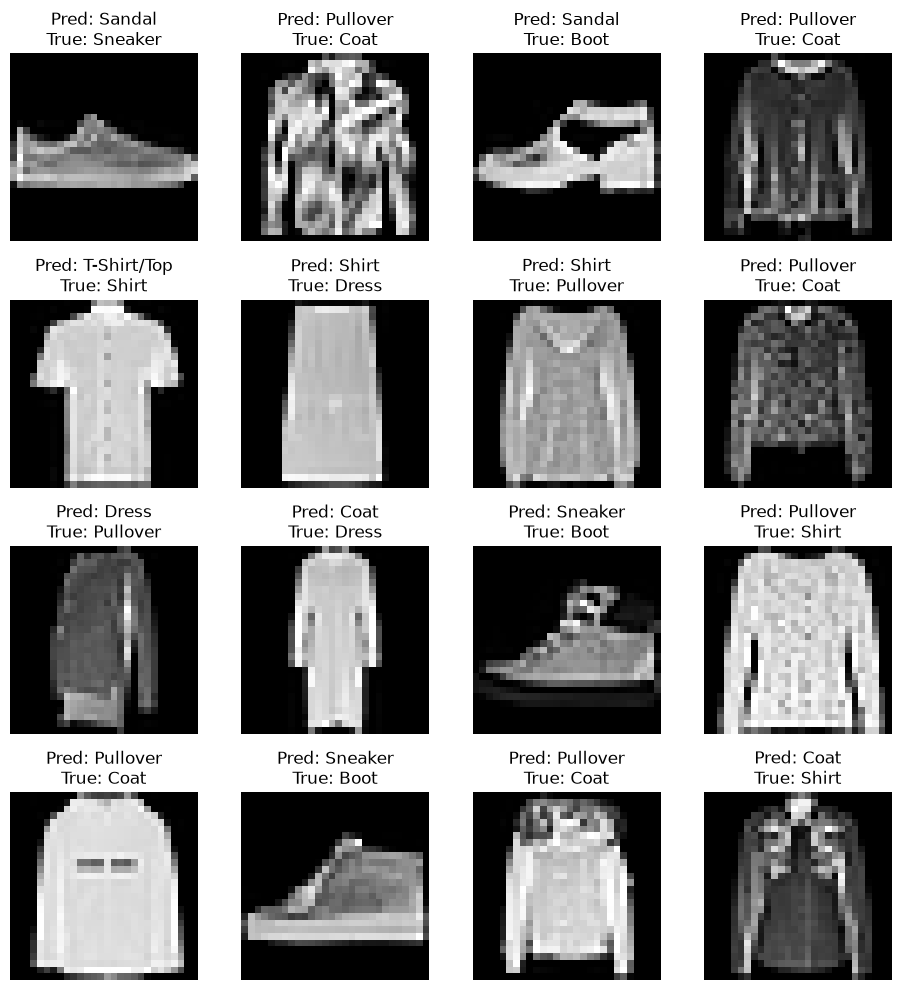

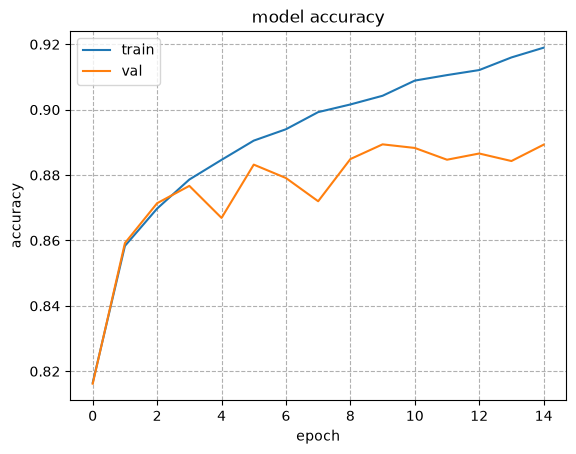

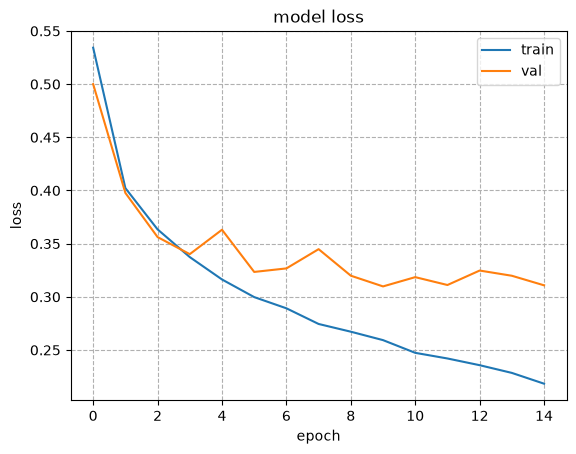

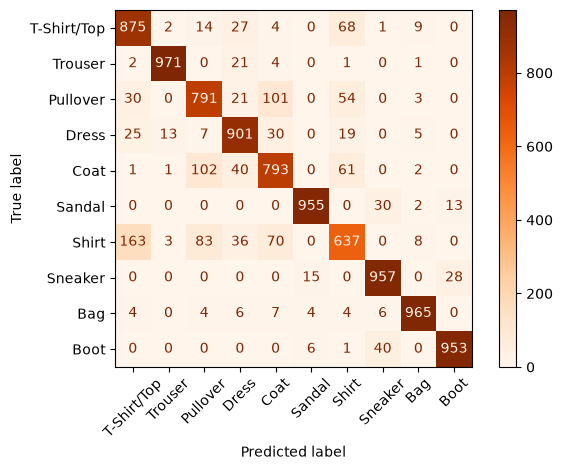

In [10]:
# Teste do modelo
#

# restaurar o melhor modelo que foi encontrado
model.load_weights(BEST_MODEL_PATH)

# obter predições no conjunto de teste ground truth
y_pred = model.predict(x_test)
pred_ids = np.argmax(y_pred, axis = 1)
true_ids = np.argmax(y_test, axis = 1)

# calcular acertos no conjunto de teste
n_misses = np.count_nonzero(true_ids != pred_ids)
n_preds = pred_ids.shape[0]
accuracy = (n_preds - n_misses) / n_preds

print("Falhou {:d} de {:d} exemplos".format(n_misses, n_preds))
print("Taxa de acertos: {:.2f} %".format(accuracy * 100))

# gerar uma matriz de confusão
cm = confusion_matrix(true_ids, pred_ids)


########################################################################
# Mostrar figuras

# exemplos de imagens onde falhou
missesIdx = np.flatnonzero(true_ids != pred_ids)
plt.figure(1, figsize=(10, 10))
for i in range(0, 16):
    idx = missesIdx[i]
    image = x_test[idx,:,:] * 255
    ax = plt.subplot(4, 4, i+1)
    plt.imshow(image,cmap="gray")
    plt.title("Pred: " + LABELS[pred_ids[idx]] + "\nTrue: " + LABELS[true_ids[idx]])
    plt.axis("off")
    plt.tight_layout()

# evolução dos acertos
plt.figure(2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc="upper left")
plt.grid(True, ls='--')

# evolução da loss
plt.figure(3)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc="upper right")
plt.grid(True, ls='--')

# matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap="Oranges", xticks_rotation=45)
plt.tight_layout()
plt.show()